In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

In [28]:
# Set project directory
superset = "Lindsay"
project = "H358"
segmentation = "stardist_lrwb"
project_path = Path(f"../data/{superset}/{project}").resolve()
print(f"Root directory = {project_path}")

Root directory = /Users/miguelibarra/PycharmProjects/cin/data/Lindsay/H358


In [29]:
# Read in masterfile and get modifications and folders
# Please be sure masterfile is uptodate
masterfile = pd.read_csv(f"../data/masterfile.csv")
# masterfile = masterfile[masterfile['cell_line_only'] == cell_line]
mods = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['cell_line']))
folder = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['folder']))
cell_line = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['cell_line_only']))
time = dict(zip(masterfile['file'].apply(lambda x: x.split(".")[0]), masterfile['time']))

In [30]:
# Collect results
results = []
for file in (project_path / "predictions" / segmentation).iterdir():
    if str(file).endswith("_summary.csv"):
        # print(file)
        df = pd.read_csv(file).rename(columns={"micronuclei": "", "count":file.name.split("_su")[0]}).set_index('')
        results.append(df)

# Concatenate results
results = pd.concat(results, axis=1).sort_index().T.sort_index()
results.index.name = "file"
results = results.reset_index()
results

,file,0,1,2,3,4,5,cells_with_micronuclei,cells_with_micronuclei_ratio,micronuclei_ratio,total_cells,total_micronuclei
0,0h_H358_gfp_dnMCAK_v2_070923_s01,737.0,23.0,NaN,NaN,NaN,NaN,23.0,0.030263,0.030263,760.0,23.0
1,0h_H358_gfp_dnMCAK_v2_070923_s02,776.0,12.0,NaN,NaN,NaN,NaN,12.0,0.015228,0.015228,788.0,12.0
2,0h_H358_gfp_dnMCAK_v2_070923_s03,722.0,23.0,2.0,NaN,NaN,NaN,25.0,0.033467,0.036145,747.0,27.0
3,0h_H358_gfp_dnMCAK_v2_070923_s04,782.0,21.0,NaN,NaN,NaN,NaN,21.0,0.026152,0.026152,803.0,21.0
4,0h_H358_gfp_dnMCAK_v2_070923_s05,747.0,19.0,3.0,NaN,NaN,NaN,22.0,0.028609,0.032510,769.0,25.0
5,0h_H358_gfp_dnMCAK_v2_070923_s06,711.0,20.0,NaN,NaN,1.0,NaN,21.0,0.028689,0.032787,732.0,24.0
6,0h_H358_gfp_dnMCAK_v2_070923_s07,542.0,8.0,NaN,NaN,NaN,NaN,8.0,0.014545,0.014545,550.0,8.0
7,0h_H358_gfp_dnMCAK_v2_070923_s08,521.0,30.0,2.0,NaN,NaN,NaN,32.0,0.057866,0.061483,553.0,34.0
8,0h_H358_gfp_dnMCAK_v2_070923_s09,595.0,11.0,1.0,NaN,NaN,NaN,12.0,0.019769,0.021417,607.0,13.0
9,0h_H358_gfp_dnMCAK_v2_070923_s10,619.0,14.0,1.0,NaN,NaN,NaN,15.0,0.023659,0.025237,634.0,16.0


In [31]:
results["cell_line"] = results["file"].apply(lambda x: cell_line[x.split("_su")[0]])
results["cell_line_mod"] = results["file"].apply(lambda x: mods[x.split("_su")[0]])
results["folder"] = results["file"].apply(lambda x: folder[x.split("_su")[0]])
results["time"] = results["file"].apply(lambda x: time[x.split("_su")[0]])
results

,file,0,1,2,3,4,5,cells_with_micronuclei,cells_with_micronuclei_ratio,micronuclei_ratio,total_cells,total_micronuclei,cell_line,cell_line_mod,folder,time
0,0h_H358_gfp_dnMCAK_v2_070923_s01,737.0,23.0,NaN,NaN,NaN,NaN,23.0,0.030263,0.030263,760.0,23.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
1,0h_H358_gfp_dnMCAK_v2_070923_s02,776.0,12.0,NaN,NaN,NaN,NaN,12.0,0.015228,0.015228,788.0,12.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
2,0h_H358_gfp_dnMCAK_v2_070923_s03,722.0,23.0,2.0,NaN,NaN,NaN,25.0,0.033467,0.036145,747.0,27.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
3,0h_H358_gfp_dnMCAK_v2_070923_s04,782.0,21.0,NaN,NaN,NaN,NaN,21.0,0.026152,0.026152,803.0,21.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
4,0h_H358_gfp_dnMCAK_v2_070923_s05,747.0,19.0,3.0,NaN,NaN,NaN,22.0,0.028609,0.032510,769.0,25.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
5,0h_H358_gfp_dnMCAK_v2_070923_s06,711.0,20.0,NaN,NaN,1.0,NaN,21.0,0.028689,0.032787,732.0,24.0,H358,H358,0h_H358_gfp_dnMCAK_v2_070923,0h
6,0h_H358_gfp_dnMCAK_v2_070923_s07,542.0,8.0,NaN,NaN,NaN,NaN,8.0,0.014545,0.014545,550.0,8.0,H358,H358-GFP,0h_H358_gfp_dnMCAK_v2_070923,0h
7,0h_H358_gfp_dnMCAK_v2_070923_s08,521.0,30.0,2.0,NaN,NaN,NaN,32.0,0.057866,0.061483,553.0,34.0,H358,H358-GFP,0h_H358_gfp_dnMCAK_v2_070923,0h
8,0h_H358_gfp_dnMCAK_v2_070923_s09,595.0,11.0,1.0,NaN,NaN,NaN,12.0,0.019769,0.021417,607.0,13.0,H358,H358-GFP,0h_H358_gfp_dnMCAK_v2_070923,0h
9,0h_H358_gfp_dnMCAK_v2_070923_s10,619.0,14.0,1.0,NaN,NaN,NaN,15.0,0.023659,0.025237,634.0,16.0,H358,H358-GFP,0h_H358_gfp_dnMCAK_v2_070923,0h


In [32]:
# Save results
results.to_csv(project_path /  f"{segmentation}_summary_predictions.csv", index=False)

/Users/miguelibarra/.miniconda3/envs/stable/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


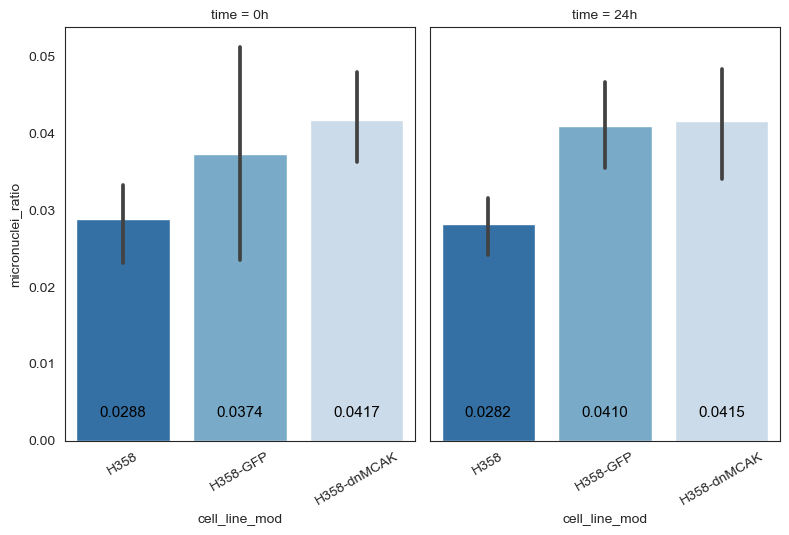

In [33]:
# Set style
sns.set_style("white")

# Plot
g =sns.catplot(data=results, x="cell_line_mod", y="micronuclei_ratio", col="time", kind="bar", palette="Blues_r", height=5, aspect=0.8)

# Despine
sns.despine(right=False,top=False)

# iterate through axes plot values
for ax in g.axes.ravel():
    for c in ax.containers:
        for p in ax.patches:
            ax.annotate("%.4f" % p.get_height(), (p.get_x() + p.get_width() / 2., 0),
                        ha='center', va='center', fontsize=11, color='black', rotation=0, xytext=(0, 20),
                        textcoords='offset points')


g.set_xticklabels(rotation=30)

# Create output directory in case it doesn't exist
Path(project_path/"figures").mkdir(exist_ok=True)
plt.savefig(project_path/ "figures" / f"{segmentation}_dist_black.png", dpi=300, transparent=True)
plt.savefig(project_path/ "figures" / f"{segmentation}_dist_black.pdf", dpi=300, transparent=True)